In [1]:
import pandas as pd

In [2]:
w=pd.read_csv("india_weather_100cities_clean.csv")
w

,city,latitude,longitude,init_time,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_type,precipitation_amount,relative_humidity,wind_direction,wind_speed,weather
0,Mumbai,19.076,72.877,2026-03-29 12:00:00,3,29.0,1,-4.0,none,0,65,NW,3.0,clearnight
1,Mumbai,19.076,72.877,2026-03-29 12:00:00,6,28.0,1,-1.0,none,0,68,NW,3.0,clearnight
2,Mumbai,19.076,72.877,2026-03-29 12:00:00,9,27.0,1,-1.0,none,0,65,N,3.0,clearnight
3,Mumbai,19.076,72.877,2026-03-29 12:00:00,12,27.0,1,-1.0,none,0,71,N,2.0,clearnight
4,Mumbai,19.076,72.877,2026-03-29 12:00:00,15,28.0,1,-4.0,none,0,60,N,2.0,clearday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6587,Panaji,15.496,73.828,2026-03-29 12:00:00,180,23.0,1,-1.0,none,0,95,N,2.0,humidnight
6588,Panaji,15.496,73.828,2026-03-29 12:00:00,183,28.0,1,-1.0,none,0,62,N,3.0,clearday
6589,Panaji,15.496,73.828,2026-03-29 12:00:00,186,33.0,1,-1.0,none,-1,62,W,3.0,tsday
6590,Panaji,15.496,73.828,2026-03-29 12:00:00,189,33.0,1,2.0,none,1,25,W,3.0,clearday


In [3]:
len(w['city'].unique())

103

In [4]:
w.columns

Index(['city', 'latitude', 'longitude', 'init_time', 'timepoint_hr',
       'temperature_c', 'cloud_cover', 'lifted_index', 'precipitation_type',
       'precipitation_amount', 'relative_humidity', 'wind_direction',
       'wind_speed', 'weather'],
      dtype='object')

In [5]:
w.columns[w.isna().any()]

Index([], dtype='object')

In [6]:
w.isna().any()

city                    False
latitude                False
longitude               False
init_time               False
timepoint_hr            False
temperature_c           False
cloud_cover             False
lifted_index            False
precipitation_type      False
precipitation_amount    False
relative_humidity       False
wind_direction          False
wind_speed              False
weather                 False
dtype: bool

In [7]:
w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6592 entries, 0 to 6591
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   city                  6592 non-null   object 
 1   latitude              6592 non-null   float64
 2   longitude             6592 non-null   float64
 3   init_time             6592 non-null   object 
 4   timepoint_hr          6592 non-null   int64  
 5   temperature_c         6592 non-null   float64
 6   cloud_cover           6592 non-null   int64  
 7   lifted_index          6592 non-null   float64
 8   precipitation_type    6592 non-null   object 
 9   precipitation_amount  6592 non-null   int64  
 10  relative_humidity     6592 non-null   int64  
 11  wind_direction        6592 non-null   object 
 12  wind_speed            6592 non-null   float64
 13  weather               6592 non-null   object 
dtypes: float64(5), int64(4), object(5)
memory usage: 721.1+ KB


In [8]:
w.isna().sum()

city                    0
latitude                0
longitude               0
init_time               0
timepoint_hr            0
temperature_c           0
cloud_cover             0
lifted_index            0
precipitation_type      0
precipitation_amount    0
relative_humidity       0
wind_direction          0
wind_speed              0
weather                 0
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder


In [10]:
l=LabelEncoder()
w['weather']=l.fit_transform(w["weather"])
w['weather']

0        1
1        1
2        1
3        1
4        0
        ..
6587     5
6588     0
6589    20
6590     0
6591     0
Name: weather, Length: 6592, dtype: int64

In [11]:
# nw=w.select_dtypes(["int64","float64"])
# nw

In [12]:
# from sklearn.preprocessing import StandardScaler

In [13]:
# s=StandardScaler()
# x1=s.fit_transform(x)
# x1

In [14]:
unique_cities = w[['city', 'latitude', 'longitude']].drop_duplicates()
unique_cities

,city,latitude,longitude
0,Mumbai,19.076,72.877
64,Delhi,28.614,77.209
128,Bangalore,12.972,77.595
192,Hyderabad,17.385,78.487
256,Ahmedabad,23.023,72.571
...,...,...,...
6272,Shillong,25.578,91.883
6336,Aizawl,23.728,92.718
6400,Itanagar,27.084,93.605
6464,Agartala,23.831,91.287


In [15]:
from sklearn.cluster import DBSCAN

coords = unique_cities[['latitude','longitude']].values

db = DBSCAN(eps=2, min_samples=3)  # increase eps
labels = db.fit_predict(coords)

unique_cities['cluster'] = labels

In [16]:
unique_cities

,city,latitude,longitude,cluster
0,Mumbai,19.076,72.877,0
64,Delhi,28.614,77.209,1
128,Bangalore,12.972,77.595,2
192,Hyderabad,17.385,78.487,0
256,Ahmedabad,23.023,72.571,3
...,...,...,...,...
6272,Shillong,25.578,91.883,7
6336,Aizawl,23.728,92.718,7
6400,Itanagar,27.084,93.605,-1
6464,Agartala,23.831,91.287,7


In [17]:
print(unique_cities['cluster'].value_counts())

cluster
 0    27
 1    22
 2    11
 3    11
 4    10
-1     9
 5     5
 7     5
 6     3
Name: count, dtype: int64


In [18]:
import matplotlib.pyplot as plt

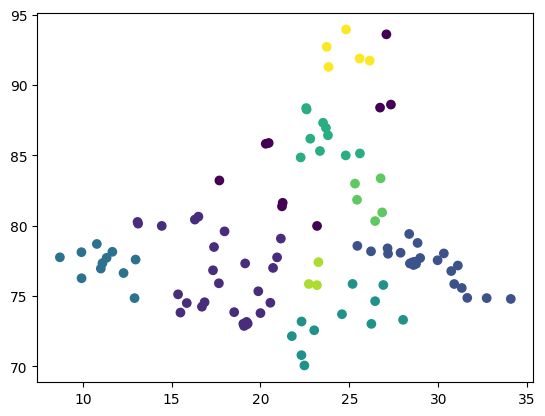

In [19]:
plt.scatter(unique_cities.iloc[:,1],unique_cities.iloc[:,2],c=labels)
plt.show()